In [ ]:
from langgraph.graph import Graph
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

## Configure the model
def llm(input):
    model=ChatGoogleGenerativeAI(model = 'gemini-1.5-flash')
    output=model.invoke(input)
    return output.content

## Configure the embedding model
embedding = HuggingFaceEmbeddings(model_name = "BAAI/bge-small-en")
embedding_dim = len(embedding.embed_query("Hi"))

c:\Users\Echo\Desktop\KNA_AgenticAI\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Echo\.cache\huggingface\hub\models--BAAI--bge-small-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP d

In [ ]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

## Creating vector database - Take data, embed it and store it in vector DB
loader = DirectoryLoader("../data", glob="./*.txt", loader_cls=TextLoader)
text_docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 200,  chunk_overlap = 50)
splitted_text_docs = text_splitter.split_documents(text_docs)

db = FAISS.from_documents(splitted_text_docs, embedding)
retriever = db.as_retriever(search_kwargs = {"k" : 3})
retriever.invoke("Industrial growth of USA?")


[Document(id='f78c37bd-cae6-4faa-8747-dd2a716e98ed', metadata={'source': '..\\data\\usa.txt'}, page_content='Looking forward, the U.S. economy is expected to grow at a moderate pace, powered by innovation in AI, green energy, robotics, biotech, and quantum computing. The Biden administrationâ€™s Inflation'),
 Document(id='ccef0616-b296-4ad1-9bb8-ce747613c1ca', metadata={'source': '..\\data\\usa.txt'}, page_content='ðŸ‡ºðŸ‡¸ Overview of the U.S. Economy'),
 Document(id='1cb4ce7b-8642-4ac5-9bf3-a9a234fc0521', metadata={'source': '..\\data\\usa.txt'}, page_content='The U.S. economy remains the engine of global growth, backed by unmatched innovation, financial dominance, and a strong institutional framework. Its $28 trillion GDP and influence over global')]

In [48]:
from pydantic import BaseModel, Field
from langchain.output_parsers import PydanticOutputParser
import operator
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage

class TopicSelectionParser(BaseModel):
    Topic: str = Field(description = "Selected topic.")
    Reasoning: str = Field(description = "Reasoning behind topic selection.")

parser = PydanticOutputParser(pydantic_object = TopicSelectionParser)
print(parser.get_format_instructions())

## Just a example AgentState
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"Topic": {"description": "Selected topic.", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection.", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
```


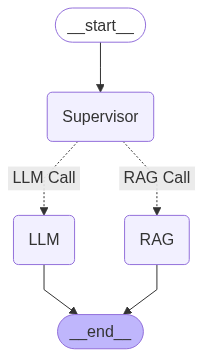

In [70]:
from langgraph.graph import StateGraph, END
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

def SuperVisor(state: AgentState):
    question = state["messages"][-1]
    print("Question", question)

    template = '''
    Your task is to classify the given user query into one of the following categories: [USA, Not Related].
    Only respond with the category name and nothing else.

    User query: {question}
    {format_instructions}
    '''

    prompt = PromptTemplate(
        template = template,
        input_variable = ["question"],
        partial_variables = {"format_instructions" : parser.get_format_instructions()}
    )

    chain = prompt|llm|parser
    response = chain.invoke({"question": question})
    print("Parsed Output", response)

    return {"messages" : [response.Topic]}

## RAG Function
def function_2(state: AgentState):
    print("-> RAG Call ->")

    question = state["messages"][0]

    prompt = PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don’t know the answer, just say that you don’t know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:""",
        input_variables=['context', 'question']
    )

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    result = rag_chain.invoke(question)
    return {"messages": [result]}

## LLM Function
def function_3(state: AgentState):
    print("-> LLM Call ->")

    question = state["messages"][0]

    # Normal LLM call
    complete_query = "Answer the follow question with your knowledge of the real world. Following is the user question: " + question
    response = llm(complete_query)
    return {"messages": [response]}

def router(state: AgentState):
    print("-> Router ->")
    last_message = state["messages"][-1]

    if "usa" in last_message.lower():
        return "RAG Call"
    else:
        return "LLM Call"

workflow = StateGraph(AgentState)

workflow.add_node("Supervisor",  SuperVisor)
workflow.add_node("RAG",  function_2)
workflow.add_node("LLM",  function_3)

workflow.set_entry_point("Supervisor")
workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG Call" : "RAG",
        "LLM Call" : "LLM"
    }
)

workflow.add_edge("RAG", END)
workflow.add_edge("LLM", END)

app = workflow.compile()
app

In [73]:
state = {"messages": ["Can you tell me the industrial growth of world's most poor economy"]}
app.invoke(state)

Question Can you tell me the industrial growth of world's most poor economy
Parsed Output Topic='Not Related' Reasoning="The query asks about the industrial growth of the world's poorest economy, which is a global economic topic and not specific to the USA."
-> Router ->
-> LLM Call ->


{'messages': ["Can you tell me the industrial growth of world's most poor economy",
  'Not Related',
  'It\'s impossible to give a precise figure for the industrial growth of the "world\'s most poor economy" because:\n\n1. **Defining "most poor" is complex:**  Poverty is measured in various ways (GDP per capita, poverty rates, Human Development Index, etc.), and different metrics will yield different "poorest" countries.  The ranking can also shift frequently.\n\n2. **Data reliability is an issue:**  Reliable industrial growth data is often lacking in the poorest economies.  Informal economies are substantial in many of these nations, making accurate measurement extremely difficult.  Statistical agencies may lack the resources or capacity for comprehensive data collection.\n\n3. **"Industrial growth" itself is broad:**  Does this refer to manufacturing output, mining, construction, or a broader definition of industrial activity?  The answer will vary depending on the specific definitio

Assignment: 4

- You have to create one supervisor node
- Create router function
- 3 nodes: Route through LLM call, RAG Call, Web Crawler (Tavily)
- Create one more node for validation of generated output --> Explore the validation
- If validation fails, again go to supervisor and then supervisor will again decide what needs to be called next.
- Once validation pass, then only generate the final output